# **PROJECT 3A**

---
Paul CANDELIER



**The objective of the project is to analyze spurious correlations and implement methods to reduce their impacts on predictions.**

**Spurious correlations: models make decisions based on irrelevant characteristics that may appear in the training data.**

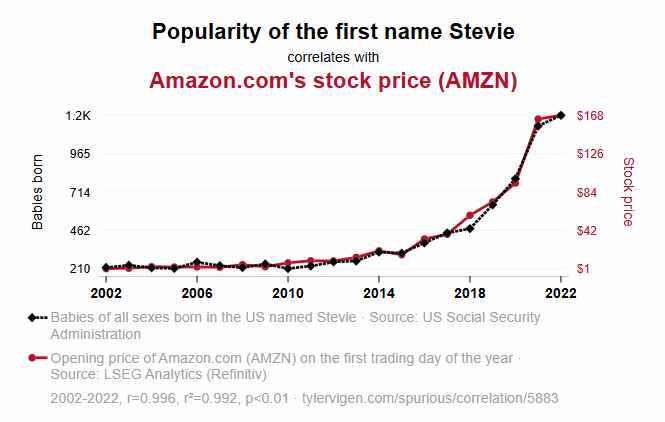

Sites to explore :

- https://scisimple.com/fr/articles/2025-07-17-reduire-la-correlation-spurious-dans-les-modeles-de-machine-learning--ak58pnn
- https://datascientest.com/grad-cam

## **Libraries importation**

In [ ]:
!pip install pytorch-lightning

!pip install tensorboard

!pip install grad-cam

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

#Deep learning part
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import os
import cv2
import argparse
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.utils.data import Dataset
import random
import torch.optim as optim
from torch.nn import functional as F
from torchmetrics.classification import Accuracy

import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule, Trainer

from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

To know if GPUs are availables.

In [ ]:
if torch.cuda.is_available():
    print("GPU available !")
    print("Name of GPU :", torch.cuda.get_device_name(0))
else:
    print("GPU unavailable, CPU has to be used")

# **I.Spurious correlation discovery**

![](https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExM2xzM25iNmF2aXljendnaWttZGh2NzBnMWRwaXFjcjJjN3RsNHV2aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3o7aCYGHw7x1YkGYVi/giphy.gif)

## **Highlighting the spurious correlation**

First, we will highlight the spurious correlation of a model with the dataset named 'Waterbirds'.

The dataset is composed of birds on a background.
On each image there is : **Either one Waterbird or one Landbird**.

for the background : **land or water**.

So we have 4 groups :
- Waterbird 🦆 on land 🌲
- Waterbird 🦆 on water 💧
- Landbird 🐦 on land🌲
- Landbird 🐦 on water💧

We try **to classify the type of the bird**.

 In the training set, birds are correctly placed on the good background. The model will be focused on the background unlike the bird to classify it, the accuracy of training set will be very high (overfitting). But in the test set, birds are placed equally on correct and uncorrect backgrounds. Here the model which has focus the learning on the background will be lost and will have a low accuracy.

The **goal** here is **to show spurious correlation** based on a misinformation of **the background**.

## **Importation of WaterBirds Dataset and comprehension**

![](https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExbWhqb3BxZG0wNjE2cnRvbTNpZzNwbzBodTVycmVraXlscHVlYjE0eSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/B81XkL3dtnWTe/giphy.gif)

### **Importation of dataset**

In [ ]:
# Load the Waterbirds dataset from Hugging Face
dataset = load_dataset("grodino/waterbirds")

### **Discovery of the dataset**

In [ ]:
# Explore the dataset
print(dataset)
print(dataset.keys())
print(dataset['train'][0])  # View the first training sample

test_img = dataset['test'][25]['image']
print(plt.imshow(test_img))
print(test_img.mode)

print(test_img.split())

R = np.array(test_img.split()[0])
G = np.array(test_img.split()[1])
B = np.array(test_img.split()[2])

print(np.mean(R)/256)
print(np.mean(G)/256)
print(np.mean(B)/256)



print('\n-------------------------------\n')

# take some image in the test dataset and show it and each image information.
def discover_dataset(number_of_samples):
    """
    Input:
      number_of_samples: number of image to show.

    Returns:
      None.
      Show the images and each image information.
    """

    number_of_line = int(number_of_samples/5)
    plt.figure()
    for i in range(1,number_of_samples+1):
        plt.subplot(number_of_line,5,i)
        plt.imshow(dataset['train'][i]['image'])
        print(dataset['train'][i])
    plt.show()

discover_dataset(5)
#each image has not the same size.

### **Comprehension of the proportion in the dataset**

In [ ]:
def explore_data(split_name):
    """
    Input:
      split_name: the different section of the dataset : train,test,validation.

    Returns:
      None.
      Show the proportion of landbird and waterbeard with land or water background.
    """
    data = dataset[split_name]
    rows = []
    for i in range(len(data)):
        sample = data[i]
        label = sample["label"]  # 0 = landbird, 1 = waterbird
        bg = sample.get("background", sample.get("place", None))
        rows.append({"label": label, "background": bg})
    df = pd.DataFrame(rows)
    print(f"\n=== {split_name.upper()} ===")
    print("Number of images :", len(df))
    print("\nCross table (label × background) :")
    crosstab = pd.crosstab(df["label"], df["background"])
    print(crosstab)
    print("\nProportions (normalized per line) :")
    print(pd.crosstab(df["label"], df["background"], normalize="index"))
    return

# Explore
train_df = explore_data("train")
val_df = explore_data("validation")
test_df = explore_data("test")

### **Understanding**

The training set has a proportion of 95% of good correlation (the bird is in the good background) between birds and backgrounds but the validation set and the test set have a proportion of 50% of good correlation. This is prepare in order to show the spurrious correlation on this dataset.

In order to normalize data and improve the model we have to find the mean and the var of each component of the RGB.

In [ ]:
def get_mean_std(dataset):
  """
  Input:
    dataset: the waterbird dataset

  Returns:
    mean: the mean of the dataset on R,G and B.
    std: the std of the dataset on R,G and B.
  """

  mean = []
  std = []
  for part in dataset.keys():
    print('Compute the mean and std of the part : ' + part +'.')
    print('\n------------------------------------------\n')
    mean_part = []
    std_part = []
    for i in range(len(dataset[part])):
      img = dataset[part][i]['image']
      img_split = img.split()

      R = np.array(img.split()[0])
      G = np.array(img.split()[1])
      B = np.array(img.split()[2])

      mean_part.append([np.mean(R),np.mean(G),np.mean(B)])
      std_part.append([np.std(R),np.std(G),np.std(B)])

    mean_part = np.mean(mean_part, axis = 0)
    std_part = np.mean(std_part, axis = 0)

    mean.append(mean_part)
    std.append(std_part)

  mean = np.mean(mean, axis = 0)
  std = np.mean(std, axis = 0)

  for m in range(len(mean)):
    mean[m] = mean[m]/256
    std[m] = std[m]/256

  mean = list(mean)
  std = list(std)


  return mean, std


WaterbirdsDataset__RGB_means, WaterbirdsDataset__RGB_stds = get_mean_std(dataset)

print('Normalized Means of the R,G and B Waterbirds Dataset : ', WaterbirdsDataset__RGB_means)
print('Normalized Stds of the R,G and B Waterbirds Dataset : ', WaterbirdsDataset__RGB_stds)

## **Simple model and results**

### **Implementation of the simple CNN**

First we custom the dataset in order to adapt it to the dataloader.

In [ ]:
class WaterbirdsDataset(Dataset):
    """
    Custom dataset for the Waterbirds dataset.
    """
    def __init__(self, hf_split, transform=None):
        super().__init__()
        self.hf_split = hf_split # Store the split of the hugging face dataset, for example : train
        self.transform = transform # Store the transform to apply to images

    def __len__(self):
        return len(self.hf_split) # The length of the split

    def __getitem__(self, idx):
        sample = self.hf_split[idx] # Select the sample with index idx
        image = sample["image"] # Select the image
        if not isinstance(image, Image.Image): # Verify if it's a PIL.Image and convert it if it's not the case
            image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image) # transform the image
        label = torch.tensor(sample["label"], dtype=torch.long) # convert the label in a tensor with a long type for the cross entropy loss
        bg = sample.get("background", sample.get("place", None)) # get the label of background or place if the key is different or None
        return image, label, bg


Test in order to verify the output of the class WaterbirdDataset.

In [ ]:
#Test

transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()])

test_data = WaterbirdsDataset(dataset['train']).__getitem__(0)

print(test_data[0])
print(np.shape(np.array(test_data[0])))

test_data = WaterbirdsDataset(dataset['train'],transform).__getitem__(0)

print(test_data[0])
print(test_data[1])
print(int(test_data[1]))
print(np.shape(np.array(test_data[0])))



Prepare the dataloaders in order to fill it with the pl.LightningModule model.

In [ ]:
def prepare_dataloaders(batch_size=64, img_size=128): # img_size define the size to resize images in order to uniform the dataset size

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean= WaterbirdsDataset__RGB_means, # We use the real data mean and std computed previously.
                             std= WaterbirdsDataset__RGB_stds),
    ])


    # Creation of Waterbird dataset for each part, in order to fill it with the good caracteristics to the Dataloader from torch.utils.data
    train_ds = WaterbirdsDataset(dataset["train"], transform)
    val_ds = WaterbirdsDataset(dataset["validation"], transform)
    test_ds = WaterbirdsDataset(dataset["test"], transform)

    # Create dataloader for the training part and test part

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader




Build a simple CNN to show the spurrious correlation.

In [ ]:
class SimpleCNN(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)), #Adaptative in order a mean value for each features.
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

        self.loss_fn = nn.CrossEntropyLoss()
        self.acc_train = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_val = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_test = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_train(logits, y)
        self.log("train_loss", loss, on_epoch=True)
        self.log("train_acc", acc, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_val(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        acc = self.acc_test(logits, y)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

###**Results**

Train and test the model using the pl.lightgning class used in lab.

In [ ]:

print("----------------------\n Simple CNN results \n----------------------")

train_loader, val_loader, test_loader = prepare_dataloaders()

model_CNN = SimpleCNN(num_classes=2, lr=1e-3)

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(model_CNN, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(model_CNN, test_loader)

Results : The test accuracy is very low, the classifier is almost at the level of a random classifier. So we are convinced there is a problem of predictions.

In [ ]:
# Tests on types and shapes

a = torch.randn(3,128,128)
print(a)
print(np.shape(np.array(a)))

model_CNN(test_data[0].unsqueeze(0))

print(model_CNN)


Tensorboard in order to visualize results.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir tb_logs

## **Medium model and results**

In [ ]:
class MediumCNN(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3):
        super().__init__()
        self.lr = lr

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

        self.model = nn.Sequential(
            self.features,
            self.classifier
        )


        self.loss_fn = nn.CrossEntropyLoss()
        self.acc_train = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_val = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_test = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


    def training_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_train(logits, y)
        self.log("train_loss", loss, on_epoch=True)
        self.log("train_acc", acc, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_val(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        acc = self.acc_test(logits, y)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [ ]:
train_loader, val_loader, test_loader = prepare_dataloaders()

model_medium_CNN = MediumCNN(num_classes=2, lr=1e-3)

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(model_medium_CNN, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(model_medium_CNN, test_loader)

In [ ]:
print(model_medium_CNN)
print('------------------------')
print(model_medium_CNN.features[11])

## **Complex model and results**

In [ ]:
base_model = models.resnet18(pretrained=True)
base_model.fc = nn.Linear(base_model.fc.in_features, 2)

print(base_model.layer4[1].conv2)

class ComplexModel(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.model = base_model

        self.loss_fn = nn.CrossEntropyLoss()
        self.acc_train = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_val = Accuracy(task="multiclass", num_classes=num_classes)
        self.acc_test = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_train(logits, y)
        self.log("train_loss", loss, on_epoch=True)
        self.log("train_acc", acc, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.acc_val(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        acc = self.acc_test(logits, y)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [ ]:
train_loader, val_loader, test_loader = prepare_dataloaders()

cplx_model = ComplexModel(num_classes=2, lr=1e-3)

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=10,logger=logger)

trainer.fit(cplx_model, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(cplx_model, test_loader)

## **Analysis of spurious correlation**

### **Accuracy by group**

With the next code, we can have a first idea of the problem. We will compute the accuracy of each couple : (0, 'land'), (0, 'water'), (1, 'land'), (1, 'water') in the test set. We will see how the accuracy is different according the couple of type of birds and background.

In [ ]:
#TODO the explanation

def accuracy_by_group(model, dataloader, device):
    """
    Compute the accuracy on the group (label × background).
    """
    model.eval() # mode eval
    model.to(device) # switch the device of the weights

    group_correct = {} #True positive
    group_total = {} #Total

    # Init of 4 groups : (0, 'land'), (0, 'water'), (1, 'land'), (1, 'water')
    labels = [0, 1]
    backgrounds = ['land', 'water']
    for l in labels:
        for bg in backgrounds:
            group_correct[(l, bg)] = 0
            group_total[(l, bg)] = 0

    with torch.no_grad(): # remove the gradiant computation
        for x, y, bg in dataloader:
            x = x.to(device)
            y = y.to(device) # move x and y on the same device than the model

            logits = model(x) # outpout of the model : non normalized scores
            preds = torch.argmax(logits, dim=1) # Find the index of the maximum value along each row
            #print(y)
            #print(len(y))

            for i in range(len(y)):

                label = y[i].item() # take the i-th y (label) of the batch and convert the tensor in int with .item()
                background = 'land' if bg[i] in [0, 'land'] else 'water'
                group_total[(label, background)] += 1
                if preds[i].item() == label:
                    group_correct[(label, background)] += 1 # if the prediction is correct -> increment

    # Compute the accuracy per group
    results = []
    #print(group_correct)
    #print(group_total)
    for key in group_correct:
        correct = group_correct[key]
        total = group_total[key]
        acc = correct / total if total > 0 else 0
        results.append({
            "label": key[0],
            "background": key[1],
            "accuracy": acc,
            "total": total
        })

    df = pd.DataFrame(results)
    return df

# Show results
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df_group_acc = accuracy_by_group(model_CNN, test_loader, device)
print(df_group_acc)

# Creation of a 2D table.
heat_data = df_group_acc.pivot(index="label", columns="background", values="accuracy")
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Accuracy per group (label × background)")
plt.show()


The results are irrevocable. When the bird is on the corresponding background (water bird on water and land bird on land) the accuracy is very high. However when there is a mix the accuracy decrease under 25%. It's a first indication regarding the spurrious correlation of the model. The model is focused on the background and not the bird in order to predict.

Accuracy per group on the simple model

In [ ]:
df_group_acc = accuracy_by_group(model_CNN, test_loader, device)
print(df_group_acc)

Accuracy per group on the medium model

In [ ]:
df_group_acc = accuracy_by_group(model_medium_CNN, test_loader, device)
print(df_group_acc)

Accuracy per group on the complex model

In [ ]:
df_group_acc = accuracy_by_group(cplx_model, test_loader, device)
print(df_group_acc)

We can see that the reaction of the simple and medium CNN are more unaccurate on the groups which are less represented in the training set. Contrary to the complex model which detect more and have a better efficiency regarding the minority group.

### **Implementation of the Grad-CAM**

An interesting method to depict the spurious correlation is the Grad-CAM method. This method allows to observe where the Convolution layer gives the more weights in the image.

We have to use the Grad-CAM, with this function we can plot the Grad-CAM of each sample on each possible predictions. If the example is labeled 1, however we have 2 corresponding tensors during the prediction for label 0 and 1. We can compute each Grad-CAM corresponding to Tensors of label 0 or label 1.

But in order to show the spurious correlation of the model, we will show the Grad-CAM concerning the label of the predictions of the model.

First we define some functions to visualize the output of some predictions.

#### **Visualization functions**

In [ ]:
# Extract some test predictions to test

model_CNN.eval() #evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_CNN.to(device)

for i in range(10):
  with torch.no_grad():
      img, label, bg = WaterbirdsDataset(dataset['test'],transform).__getitem__(i)
      img = img.unsqueeze(0).to(device) #add a dimension in order to have a batch and place it on the same device
      y_hat = model_CNN(img)          # logits
      pred_class = torch.argmax(y_hat, 1)
      print("Classe prédite:", pred_class.item(), " | Classe réelle:", label.item())

print('\n---------------------------\n')

def prediction_and_reality(sample_idx,set_of_images,model):
  """
  Input:
    sample_idx: the idx of the sample chosen in the set_of_images
    set_of_images: the different section of the dataset : train,test,validation.
    model: the model to use.

  Returns:
    a list with the predicted class and the reality class.
  """
  model.eval() #evaluation mode
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model_CNN.to(device)
  with torch.no_grad():
    img, label, bg = WaterbirdsDataset(dataset[set_of_images],transform).__getitem__(sample_idx)
    img = img.unsqueeze(0).to(device) #add a dimension in order to have a batch and place it on the same device
    y_hat = model(img)          # logits
    pred_class = torch.argmax(y_hat, 1)

  return([pred_class.item(),label.item()])

print(prediction_and_reality(0,'test',model_CNN))

def Is_the_prediction_correct(prediction_and_reality, Bool = True):
  """
  Input:
    prediction_and_reality: The previous function
    Bool: If True return value else return string to inform

  Output:
    return (0 or 1) or a string to inform

  """
  if Bool == True :
    if prediction_and_reality[0] == prediction_and_reality[1]:
      return 1
    else :
      return 0

  else :
    if prediction_and_reality[0] == prediction_and_reality[1]:
      return "The prediction is correct"
    else :
      return "The prediction is not correct"

Is_the_prediction_correct(prediction_and_reality(0,'test',model_CNN))

#### **Grad-CAM function**

Code in order to plot the Grad-CAM.

In [ ]:
def plot_grad_cam(model, number_of_samples, set_of_images, layer = None, threshold = 0 ):
  """
  Input:
    model: The model to use
    number_of_samples : The number of input and output images
    set_of_images: the different section of the dataset : train,test,validation.
    layer: the conv layer to observe the Grad-CAM (set in accordance to CNN model if equal to None)
    threshold : The threshold of starting to observ images in the dataset. ( set to 0, the beggining of the section chosen)

  Output:
    return number_of_samples images with the Grad-CAM.
  """

  if layer is None:
      layer = model.model[6]

  for i in range(number_of_samples) :

    idx = i + threshold
    target_layers = [layer] # Choose the 6th layer of the model.

    cam_class = GradCAM(model=model, target_layers=target_layers) # Create an instance of the class GradCAM.

    # We have to choose the target label by the model, first we choose the real label.
    target_label = int(WaterbirdsDataset(dataset[set_of_images], transform).__getitem__(idx)[1])

    # If the prediction is correct the label is the real label, else we choose the other label, so the predicted label.
    # In fact simply we choose the predicted label as target label
    if Is_the_prediction_correct(prediction_and_reality(idx,set_of_images,model)):
      target_label = target_label
    else :
      if target_label == 0 :
        target_label = 1
      else :
        target_label = 0

    # In order to compute the Grad-CAM of the targeted label (So in fact not necessarly the predicted one)
    targets = [ClassifierOutputTarget(target_label)]

    # Extract the image
    rgb_img_tensor = WaterbirdsDataset(dataset[set_of_images], transform).__getitem__(idx)[0]

    # Intervert dimensions for the Grad-CAM library and normalize
    rgb_img = rgb_img_tensor.permute(1, 2, 0).numpy()  # CHW -> HWC
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # Transform to the good format Tensor the image sample for the Grad-CAM instance.
    input_tensor = WaterbirdsDataset(dataset[set_of_images], transform).__getitem__(idx)[0].unsqueeze(0).float()

    #Compute the Grad-CAM
    grayscale_cam = cam_class(input_tensor=input_tensor, targets=targets)[0, :]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.show()

    # Print some previous function to understand the case of each sample link with the Grad-CAM representation.
    print(prediction_and_reality(idx,set_of_images,model))
    print(Is_the_prediction_correct(prediction_and_reality(idx,set_of_images,model),Bool = False))






#### **GradCAM on simple CNN**

In [ ]:
plot_grad_cam(model_CNN, 5, 'test')

The background is clearly focused by the model in order to predict.

#### **GradCAM on complex model**

In [ ]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#cplx_model = cplx_model.to(device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cplx_model = cplx_model.to(device)

target_layer = cplx_model.model.layer4[1].conv2
plot_grad_cam(cplx_model, 5, 'train', layer=target_layer)
print("--------------------------------------------------")
plot_grad_cam(cplx_model, 5, 'test', layer=target_layer)

The Resnet18 model seems to be not biased by spurious correlations as simple CNN. With the Grad-CAM, we can see that it's focused on localized areas and not specially on the backgrounds.

# **II.Methods against Spurious correlation**

## **Improvement and correction of spurious correlations**

In this part, we will try to find **solutions** against spurious correlations.

Now we want **to explore several methods** in order to improve **the accuracy and robustness of models** when there is spurious correlation.

### **JTT (Just Train Twice)**

**JTT (Just Train Twice)** is a debiasing method designed to improve model robustness to spurious correlations.

- First training: Train a standard model and identify the misclassified samples, which often correspond to minority or unbiased examples.

- Second training: Train a new model while up‑weighting those hard examples.

**Force the model to learn true, causal features instead of relying on superficial correlations**.



#### **JTT Implementation**

We create error analysis in order to find the misclassified samples.

In [ ]:
def Error_analysis(model,split_name):
  """
  Input:
    model: the model to evaluate.
    split_name: the different section of the dataset : train,test,validation.

  Returns:
    e: a list contaning for each sample True if it is misclassified and False if not.
  """

  model.eval() #evaluation mode
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  data = dataset[split_name]
  e = []

  for i in range(len(data)):
    with torch.no_grad():
        img, label, bg = WaterbirdsDataset(dataset[split_name],transform).__getitem__(i)
        img = img.unsqueeze(0).to(device) #add a dimension in order to have a batch and place it on the same device
        y_hat = model(img)          # logits
        pred_class = torch.argmax(y_hat, 1)
        if pred_class.item() != label.item():
          e.append(True)
        else:
          e.append(False)

  return e

errors = Error_analysis(model_CNN,'train')

Then we create the dataloaders where the misclassified samples are upweights in order to show to the model, samples that he has to focus on and to correct.

In [ ]:
def prepare_dataloaders_JTT(model,batch_size=64, img_size=128, ponderation_weight = 3): # img_size define the size to resize images in order to uniform the dataset size

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean= WaterbirdsDataset__RGB_means, # We use the real data mean and std.
                             std= WaterbirdsDataset__RGB_stds),
    ])


    # Creation of Waterbird dataset for each part, in order to fill it with the good caracteristics to the Dataloader from torch.utils.data
    train_ds = WaterbirdsDataset(dataset["train"], transform)
    val_ds = WaterbirdsDataset(dataset["validation"], transform)
    test_ds = WaterbirdsDataset(dataset["test"], transform)

    # Create dataloader for the training part and test part

    errors = Error_analysis(model,'train')
    weights = torch.tensor([ponderation_weight if e else 1.0 for e in errors])
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=2,sampler=sampler) #Shuffle fixed to False and add the sampler.
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

Parameters to perform and visualize the JTT.

In [ ]:
# Comparison parameters
thresh = 0 # threshold on set of images in order to inspect different images results.
pond_weight = 2 # ponderation weights of the JTT method.

#### **JTT on simple CNN**

In [ ]:
model_CNN_JTT = SimpleCNN(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_CNN_JTT,ponderation_weight = pond_weight)

print("reassignment weights finished")

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(model_CNN_JTT, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(model_CNN_JTT, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(model_CNN_JTT, test_loader, device)
print(df_group_acc)

In [ ]:
plot_grad_cam(model_CNN_JTT, 5, 'test', threshold = thresh)

#### **JTT on medium CNN**

In [ ]:
model_medium_CNN_JTT = MediumCNN(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_medium_CNN_JTT,ponderation_weight = pond_weight)

print("reassignment weights finished")

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(model_medium_CNN_JTT, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(model_medium_CNN_JTT, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(model_medium_CNN_JTT, test_loader, device)
print(df_group_acc)

In [ ]:
target_layer = model_medium_CNN_JTT.features[11]
plot_grad_cam(model_medium_CNN_JTT, 5, 'test', layer = target_layer, threshold = thresh)

#### **JTT on complex model**

In [ ]:
cplx_model_JTT = ComplexModel(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(cplx_model_JTT,ponderation_weight = pond_weight)

print("reassignment weights finished")

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=20,logger=logger)

trainer.fit(cplx_model_JTT, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(cplx_model_JTT, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(cplx_model_JTT, test_loader, device)
print(df_group_acc)

In [ ]:
cplx_model_JTT = cplx_model_JTT.cuda()
plot_grad_cam(cplx_model_JTT, 20, 'test', layer = cplx_model_JTT.model.layer4[1].conv2)

In a firt view, we can consider that JTT is not efficient to solve the problem. First the ponderation weight is not obvious, so we have to try with differents on the medium CNN (for example). (Proceed in the next part.)

Secondly, this method is not enough strong alone to solve spurious correlations of this dataset.

#### **Research of the optimal ponderation weigth for JTT on the medium model**

In [ ]:
for pond_weight in [1.25,1.5,1.75,2,2.5,4,5]:
  model_medium_CNN_JTT = MediumCNN(num_classes=2, lr=1e-3)

  train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_medium_CNN_JTT,ponderation_weight = pond_weight)

  print("reassignment weights finished")

  logger = TensorBoardLogger("tb_logs", name="waterbirds")
  trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=10,logger=logger)

  trainer.fit(model_medium_CNN_JTT, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
  trainer.test(model_medium_CNN_JTT, test_loader)

  df_group_acc = accuracy_by_group(model_medium_CNN_JTT, test_loader, device)
  print(df_group_acc)

So, with these different weightings, we can see different improvements but nothing very efficient. So we have to find other methods.

### **GroupDRO**

We will use the method groupDRO : "Distributionally Robust Optimization per group".

The classic method aims to reduce the means of the loss. With the groupDRO method, we try to optimize the worst group relativ loss. Its optimize minorities. In our case it has to be efficient because the train dataset is unevenly distributed.

Theorical part :

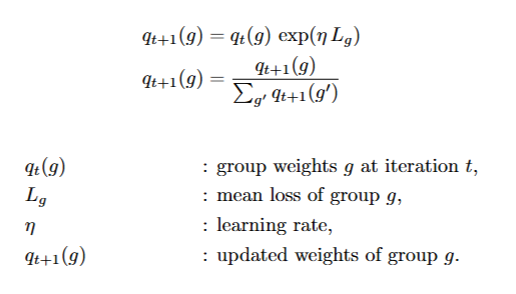

#### **GroupDRO implementation**

In [ ]:
#To comment

class GroupDROModel(pl.LightningModule):
    def __init__(self, base_model, lr=1e-3):
        super().__init__()
        self.model = base_model
        self.lr = lr

        self.loss_fn = nn.CrossEntropyLoss(reduction="none")

        self.num_groups = 4
        self.register_buffer("group_weights", torch.ones(self.num_groups) / self.num_groups)

        self.acc_val = Accuracy(task="multiclass", num_classes=2)
        self.acc_test = Accuracy(task="multiclass", num_classes=2)

    def forward(self, x):
        return self.model(x)

    # The GroupDRO method is based on the training step loss
    def training_step(self, batch, batch_idx):
        x, y, bg = batch
        logits = self(x)

        # 1. individual losses
        losses = self.loss_fn(logits, y)

        # 2. group id
        group_id = (y * 2 + bg).long()

        # 3. compute loss per group
        group_losses = torch.zeros(self.num_groups, device=self.device)
        for g in range(self.num_groups):
            mask = (group_id == g)
            if mask.any():
                group_losses[g] = losses[mask].mean()
            else :
                group_losses[g] = 0

        # 4. update adversarial weights (stable update)
        eta = 0.001
        self.group_weights = self.group_weights * torch.exp(eta * group_losses.detach())
        self.group_weights = self.group_weights / self.group_weights.sum()

        # 5. DRO loss
        dro_loss = (self.group_weights.to(self.device) * group_losses).sum()

        self.log("train_loss", dro_loss)
        return dro_loss

    def validation_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        loss = self.loss_fn(logits, y).mean()
        acc = self.acc_val(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        x, y, _ = batch
        logits = self(x)
        acc = self.acc_test(logits, y)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


#### **GroupDRO test on several models**

We will try the GroupDRO method on the different models.

#### **GroupDRO on simple CNN**

We start to implement GroupDRO on the simple CNN model in order to avoid spurious correlation.

In [ ]:
simple_model = SimpleCNN(num_classes=2, lr=1e-3).model

simple_model_DRO = GroupDROModel(simple_model)

train_loader, val_loader, test_loader = prepare_dataloaders()

logger = TensorBoardLogger("tb_logs2", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=15,logger=logger)

trainer.fit(simple_model_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(simple_model_DRO, test_loader)

In [ ]:
%tensorboard --logdir tb_logs2

In [ ]:
df_group_acc = accuracy_by_group(simple_model_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simple_model_DRO = simple_model_DRO.to(device)
plot_grad_cam(simple_model_DRO, 20, 'train', threshold = 200)

#### **GroupDRO on medium model**

In [ ]:
#Test

medium_model = MediumCNN(num_classes=2, lr=1e-3).model

print(medium_model)

medium_model_DRO = GroupDROModel(medium_model)

print(medium_model_DRO.model[0][11])

In [ ]:
medium_model = MediumCNN(num_classes=2, lr=1e-3).model

medium_model_DRO = GroupDROModel(medium_model)

train_loader, val_loader, test_loader = prepare_dataloaders()

logger = TensorBoardLogger("tb_logs2", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=15,logger=logger)

trainer.fit(medium_model_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(medium_model_DRO, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(medium_model_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
medium_model_DRO = medium_model_DRO.to(device)
target_layer_medium = medium_model_DRO.model[0][11]
plot_grad_cam(medium_model_DRO, 20, 'train', threshold = 0, layer = target_layer_medium)

#### **GroupDRO on Complex model**

We use Resnet to understand how the Group-DRO react to a complex model.

Train and test with the groupDRO method.

In [ ]:
complex_model_DRO = GroupDROModel(base_model)

train_loader, val_loader, test_loader = prepare_dataloaders()

logger = TensorBoardLogger("tb_logs", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(complex_model_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(complex_model_DRO, test_loader)


In [ ]:
df_group_acc = accuracy_by_group(complex_model_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
complex_model_DRO = GroupDROModel(cplx_model)
complex_model_DRO = complex_model_DRO.cuda()
plot_grad_cam(complex_model_DRO, 20, 'test', layer = complex_model_DRO.model.model.layer4[1].conv2)

So intuitively, the groupDRO method should not increase the results and maybe lead to a decrease regarding the accuracy of the model because the complex model is not biased by spurious correlations simply.

We can see some improvement regarding the global accuracy but it's not exactly what we want. The background is still focused by the model.


The groups are very unbalanced during the training, the average losses per group become noisy. GroupDRO ‘hunts’ the noise and degrades the main head of Resnet.

### **Combination of JTT and GroupDRO**

In the previous parts we have seen that :

- JTT helps a little, but not enough on Waterbirds.
- GroupDRO alone is unstable without sufficient signal.

So now we will try a combination of them because :

- JTT artificially creates “difficult groups”.
- GroupDRO forces the model not to ignore these groups.

**JTT makes GroupDRO applicable.**

![](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExcnJ3eXJjZHNlcXMyb2hneTB6NXM1OHh4N3dmanBkMnZvNnNwY3p0eSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/pHb82xtBPfqEg/giphy.gif)

So we will compute the combination and the results of this method association.

In [ ]:
# Comparison parameters
thresh = 0 # threshold on set of images in order to inspect different images results.
pond_weight = 2 # ponderation weights of the JTT method.

#### **Combination on simple CNN**

In [ ]:
model_CNN_JTT = SimpleCNN(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_CNN_JTT,ponderation_weight = pond_weight)

print("----------------------\n Reassignment weights finished \n----------------------")

simple_model = model_CNN_JTT.model

simple_model_JTT_and_DRO = GroupDROModel(simple_model)

logger = TensorBoardLogger("tb_logs2", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=10,logger=logger)

trainer.fit(simple_model_JTT_and_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(simple_model_JTT_and_DRO, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(simple_model_JTT_and_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
simple_model_JTT_and_DRO = simple_model_JTT_and_DRO.to(device)

plot_grad_cam(simple_model_JTT_and_DRO, 20, 'train', threshold = 0)

#### **Combination on medium CNN**

In [ ]:
model_medium_CNN_JTT = MediumCNN(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_medium_CNN_JTT,ponderation_weight = pond_weight)

print("----------------------\n Reassignment weights finished \n----------------------")

medium_model = model_medium_CNN_JTT.model

medium_model_JTT_and_DRO = GroupDROModel(medium_model)

logger = TensorBoardLogger("tb_logs2", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=10,logger=logger)

trainer.fit(medium_model_JTT_and_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(medium_model_JTT_and_DRO, test_loader)

In [ ]:
df_group_acc = accuracy_by_group(medium_model_JTT_and_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
medium_model_JTT_and_DRO = medium_model_JTT_and_DRO.to(device)

target_layer_medium = medium_model_JTT_and_DRO.model[0][11]

plot_grad_cam(medium_model_JTT_and_DRO, 20, 'train', threshold = 40, layer = target_layer_medium)

#### **Combination on complex model**

In [ ]:
cplx_model_JTT = ComplexModel(num_classes=2, lr=1e-3)

train_loader, val_loader, test_loader = prepare_dataloaders_JTT(cplx_model_JTT,ponderation_weight = pond_weight)

print("----------------------\n Reassignment weights finished \n----------------------")

cplx_model = cplx_model_JTT.model

cplx_model_JTT_and_DRO = GroupDROModel(cplx_model)

logger = TensorBoardLogger("tb_logs2", name="waterbirds")
trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=5,logger=logger)

trainer.fit(cplx_model_JTT_and_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
trainer.test(cplx_model_JTT_and_DRO, test_loader)


In [ ]:
df_group_acc = accuracy_by_group(cplx_model_JTT_and_DRO, test_loader, device)
print(df_group_acc)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cplx_model_JTT_and_DRO = cplx_model_JTT_and_DRO.to(device)

target_layer = cplx_model_JTT_and_DRO.model.layer4[1].conv2
plot_grad_cam(cplx_model_JTT_and_DRO, 5, 'train', layer=target_layer)
print("--------------------------------------------------")
plot_grad_cam(cplx_model_JTT_and_DRO, 5, 'test', layer=target_layer)

The method isn't working properly for the simple CNN with this pponderatio weight but we can see several improvements on the medium CNN but not enough on ResNet.

In order to find a little optimization of our method we will search the optimal ponderation weight in a little scale for the medium CNN.

#### **Research of the optimal ponderation weigth for JTT during the combination on the medium model**

In [ ]:
for pond_weight in [1.25,1.5,1.75,2,2.5,4,5]:
  model_medium_CNN_JTT = MediumCNN(num_classes=2, lr=1e-3)

  train_loader, val_loader, test_loader = prepare_dataloaders_JTT(model_medium_CNN_JTT,ponderation_weight = pond_weight)

  print("----------------------\n Reassignment weights finished \n----------------------")

  medium_model = model_medium_CNN_JTT.model

  medium_model_JTT_and_DRO = GroupDROModel(medium_model)

  logger = TensorBoardLogger("tb_logs2", name="waterbirds")
  trainer = pl.Trainer(accelerator='gpu', devices=1, max_epochs=10,logger=logger)

  trainer.fit(medium_model_JTT_and_DRO, train_loader, val_loader) # Here that __getitem__ is called in intern in the method with py.lightning.
  trainer.test(medium_model_JTT_and_DRO, test_loader)

  df_group_acc = accuracy_by_group(medium_model_JTT_and_DRO, test_loader, device)
  print(df_group_acc)

We can find that with this method, the accuracy for the worst groups can increase until 50% for medium CNN !

We can improve results if we understand deeply complex models !